# Práctica 1. Representación y medida de un qubit

**Asignatura:** Computación Cuántica  
**Tema 1:** Conceptos fundamentales. Superposición cuántica  
**Duración estimada:** 45-55 minutos  
**Modalidad:** Individual o por parejas

En esta práctica representaremos estados de un qubit mediante vectores complejos, comprobaremos su normalización, aplicaremos la regla de Born y simularemos medidas en la base computacional. No utilizaremos Qiskit: trabajaremos directamente con el formalismo matemático mediante NumPy.

## Objetivos

Al finalizar la práctica serás capaz de:

- Representar estados de un qubit como vectores complejos.
- Validar y normalizar vectores de estado.
- Calcular probabilidades mediante la regla de Born.
- Simular una o varias medidas en la base computacional.
- Comparar probabilidades teóricas y frecuencias experimentales.
- Analizar el efecto del número de *shots*.
- Identificar estados diferentes que producen el mismo histograma en una base concreta.

> Completa todas las celdas marcadas con `TODO` y responde en Markdown a las preguntas planteadas.

In [148]:
import numpy as np
import matplotlib.pyplot as plt

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

np.set_printoptions(precision=5, suppress=True)

## Parte A. Representación de estados

### Ejercicio 1. Base computacional

Representa los estados

$$|0\rangle=\begin{pmatrix}1\\0\end{pmatrix},\qquad |1\rangle=\begin{pmatrix}0\\1\end{pmatrix}.$$

Muestra los vectores, su forma, el tipo de sus componentes y su norma.

In [149]:
ket_0 = np.array([1, 0], dtype=complex)
ket_1 = np.array([0, 1], dtype=complex)

print(f"ket_0: {ket_0}, Forma: {ket_0.shape}, Tipo: {ket_0.dtype}, Norma: {np.linalg.norm(ket_0)}, {np.isclose(np.linalg.norm(ket_0), 1.0, atol=1e-10)}")
print(f"ket_1: {ket_1}, Forma: {ket_1.shape}, Tipo: {ket_1.dtype}, Norma: {np.linalg.norm(ket_1)}, {np.isclose(np.linalg.norm(ket_1), 1.0, atol=1e-10)}")

ket_0: [1.+0.j 0.+0.j], Forma: (2,), Tipo: complex128, Norma: 1.0, True
ket_1: [0.+0.j 1.+0.j], Forma: (2,), Tipo: complex128, Norma: 1.0, True


**Responde:**

1. ¿Por qué los arrays deben admitir números complejos?
    - Porque las amplitudes de un estado cuántico pueden ser complejas.
2. ¿Qué dimensión tiene el espacio de estados de un qubit?
    - 2
3. ¿Qué valor debe tener la norma de un estado válido?
    - 1

### Ejercicio 2. Superposiciones

Representa los siguientes estados y, para cada uno, muestra el vector, sus amplitudes, su norma y si está normalizado:

$$|\psi_1\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}$$

$$|\psi_2\rangle=\frac{\sqrt{3}}{2}|0\rangle+\frac{1}{2}|1\rangle$$

$$|\psi_3\rangle=\frac{1}{\sqrt{2}}|0\rangle+\frac{i}{\sqrt{2}}|1\rangle$$

$$|\psi_4\rangle=\frac{1+i}{2}|0\rangle+\frac{1-i}{2}|1\rangle.$$

In [150]:
# TODO: representa los cuatro estados
psi_1 = np.array([1/np.sqrt(2),     1/np.sqrt(2)],  dtype=complex)
psi_2 = np.array([np.sqrt(3)/2,     1/2],           dtype=complex)
psi_3 = np.array([1/np.sqrt(2),     1j/np.sqrt(2)], dtype=complex)
psi_4 = np.array([(1+1j)/2,         (1-1j)/2],      dtype=complex)

estados = {
    "psi_1": psi_1,
    "psi_2": psi_2,
    "psi_3": psi_3,
    "psi_4": psi_4,
}

for nombre, estado in estados.items():
    norma = np.linalg.norm(estado)
    print(f"Nombre: {nombre}, Alpha: {estado[0]:.3f}, Beta: {estado[1]:.3f}, Norma: {norma}, Normalizado: {'Si' if np.isclose(norma, 1.0, atol=1e-10) else 'No'}")

Nombre: psi_1, Alpha: 0.707+0.000j, Beta: 0.707+0.000j, Norma: 0.9999999999999999, Normalizado: Si
Nombre: psi_2, Alpha: 0.866+0.000j, Beta: 0.500+0.000j, Norma: 0.9999999999999999, Normalizado: Si
Nombre: psi_3, Alpha: 0.707+0.000j, Beta: 0.000+0.707j, Norma: 0.9999999999999999, Normalizado: Si
Nombre: psi_4, Alpha: 0.500+0.500j, Beta: 0.500-0.500j, Norma: 1.0, Normalizado: Si


**Responde:**

1. ¿Por qué no conviene comprobar números en coma flotante con `valor == 1.0`?
    - Porque por errores de redondeo al usar números en coma flotante puede perderse precisión y dar resultados incorrectos.
2. ¿Puede un estado válido contener amplitudes imaginarias?
    - Sí.
3. ¿Implica una amplitud imaginaria que la probabilidad sea imaginaria?
    - No, la probabilidad es real.

## Parte B. Validación y normalización

### Ejercicio 3. Validación de estados

Completa una función que verifique que la entrada tiene dos amplitudes, contiene valores finitos y posee norma uno. El vector nulo y los vectores con otra dimensión no son estados válidos de un qubit.

In [151]:
def es_estado_valido(estado, tolerancia=1e-10):
    """Devuelve True si `estado` representa un estado válido de un qubit."""
    try:
        vector = np.asarray(estado, dtype=complex)
    except (TypeError, ValueError):
        print(f"Error al convertir {estado} a un array de tipo complejo.")
        return False

    if vector.shape != (2,):
        print(f"El estado tiene forma {vector.shape}, pero debería ser (2,).")
        return False

    if not np.all(np.isfinite(vector)):
        print("El estado contiene valores infinitos o NaN.")
        return False

    if np.allclose(vector, 0, atol=tolerancia):
        print("El estado es el vector nulo.")
        return False

    norma = np.linalg.norm(vector)
    if not np.isclose(norma, 1.0, atol=tolerancia):
        if np.isclose(norma, 0.0, atol=tolerancia):
            print("No se puede normalizar el vector nulo.")
            return False
        else:
            print("El estado no está normalizado.")
            return False

    return True

casos = {
    "ket_0": [1, 0],
    "ket_1": [0, 1],
    "equilibrado": [1 / np.sqrt(2), 1 / np.sqrt(2)],
    "no_normalizado": [1, 1],
    "vector_nulo": [0, 0],
    "dimension_incorrecta": [1, 0, 0],
    "con_nan": [np.nan, 0],
}


for nombre, estado in casos.items():
    valido = es_estado_valido(estado)
    print(f"Nombre: {nombre!s:<21}, Estado: {estado!s:65}, Válido: {valido!s:<5}")
    print()


Nombre: ket_0                , Estado: [1, 0]                                                           , Válido: True 

Nombre: ket_1                , Estado: [0, 1]                                                           , Válido: True 

Nombre: equilibrado          , Estado: [np.float64(0.7071067811865475), np.float64(0.7071067811865475)] , Válido: True 

El estado no está normalizado.
Nombre: no_normalizado       , Estado: [1, 1]                                                           , Válido: False

El estado es el vector nulo.
Nombre: vector_nulo          , Estado: [0, 0]                                                           , Válido: False

El estado tiene forma (3,), pero debería ser (2,).
Nombre: dimension_incorrecta , Estado: [1, 0, 0]                                                        , Válido: False

El estado contiene valores infinitos o NaN.
Nombre: con_nan              , Estado: [nan, 0]                                                         , Válido: False

### Ejercicio 4. Normalización

Completa la función. Debe convertir la entrada a un array complejo, comprobar su dimensión y finitud, rechazar el vector nulo y devolver un vector de norma uno.

In [152]:
def normalizar_estado(estado):
    """Normaliza un vector de dos amplitudes complejas."""
    vector = np.asarray(estado, dtype=complex)
    if vector.shape != (2,):
        print(f"Se esperaban la forma (2,) y seibe la forma {vector.shape}.")
        return False

    if not np.all(np.isfinite(vector)):
        print("El vector debe contener solo valores finitos.")
        return False

    norma = np.linalg.norm(vector)
    if np.isclose(norma, 0.0, atol = 1e-10):
        print("El vector debe tener una norma no cero.")
        return False

    return vector / norma


vectores = [
    np.array([1, 1],            dtype=complex),
    np.array([3, 4],            dtype=complex),
    np.array([1 + 1j, 2 - 1j],  dtype=complex)
]

for i, vector in enumerate(vectores):
    norma_antes = np.linalg.norm(vector)
    vector_normalizado = normalizar_estado(vector)
    norma_despues = np.linalg.norm(vector_normalizado)
    
    print(f"Vector {i+1}:")
    print("Vector antes:",   vector,             "Norma antes:",    norma_antes)
    print("Vector después:", vector_normalizado, "Norma después:",  norma_despues)
    print()

Vector 1:
Vector antes: [1.+0.j 1.+0.j] Norma antes: 1.4142135623730951
Vector después: [0.70711+0.j 0.70711+0.j] Norma después: 0.9999999999999999

Vector 2:
Vector antes: [3.+0.j 4.+0.j] Norma antes: 5.0
Vector después: [0.6+0.j 0.8+0.j] Norma después: 1.0

Vector 3:
Vector antes: [1.+1.j 2.-1.j] Norma antes: 2.6457513110645907
Vector después: [0.37796+0.37796j 0.75593-0.37796j] Norma después: 0.9999999999999999



**Responde:**

1. ¿Cambia la dirección del vector al normalizarlo?
    - No, solo cambia de longitud.
2. ¿Qué ocurre con la relación entre sus componentes?
    - El vector normalizado conserva la relación entre sus componentes.
3. ¿Por qué no puede normalizarse el vector nulo?
    - Porque su norma es 0, habría una división por cero. Además, no tiene dirección ni representa ningún estado físico.

## Parte C. Regla de Born

### Ejercicio 5. Probabilidades de medida

Para $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$, la regla de Born establece $P(0)=|\alpha|^2$ y $P(1)=|\beta|^2$. Completa la función sin utilizar `estado ** 2`.

In [153]:
def calcular_probabilidades(estado):
    """Devuelve {0: P(0), 1: P(1)} para un estado válido."""
    if not es_estado_valido(estado, tolerancia=1e-10):
        print("El estado no es válido.")
        return None
    vector = np.asarray(estado, dtype=complex)
    prob = np.abs(vector)**2
    return {0: float(prob[0]), 1: float(prob[1])}


vectores_2 = {"ket_0": ket_0, "ket_1": ket_1, "psi_1": psi_1, "psi_2": psi_2, "psi_3": psi_3, "psi_4": psi_4}
for nombre, vector in vectores_2.items():
    probabilidades = calcular_probabilidades(vector)
    suma = probabilidades[0] + probabilidades[1]
    if probabilidades is None:
        print(f"Vector {nombre}: El estado no es válido.")
        continue
    print(f"Vector {nombre}: P(0) = {probabilidades[0]:.4f}, P(1) = {probabilidades[1]:.4f}, Suma = {suma:.4f}")

Vector ket_0: P(0) = 1.0000, P(1) = 0.0000, Suma = 1.0000
Vector ket_1: P(0) = 0.0000, P(1) = 1.0000, Suma = 1.0000
Vector psi_1: P(0) = 0.5000, P(1) = 0.5000, Suma = 1.0000
Vector psi_2: P(0) = 0.7500, P(1) = 0.2500, Suma = 1.0000
Vector psi_3: P(0) = 0.5000, P(1) = 0.5000, Suma = 1.0000
Vector psi_4: P(0) = 0.5000, P(1) = 0.5000, Suma = 1.0000


### Ejercicio 6. Cálculo manual con amplitudes complejas

Considera

$$|\psi\rangle=\frac{1+i}{2}|0\rangle+\frac{1-i}{2}|1\rangle.$$

Calcula manualmente $\alpha$, $\beta$, $|\alpha|^2$, $|\beta|^2$, $P(0)$ y $P(1)$. Después compruébalo con la función anterior.

Desarrollo:

Amplitudes: 
$$\alpha=\frac{1+i}{2}, \qquad \beta=\frac{1-i}{2}$$

Modulos al cuadrado: 
$$|\alpha|^2=\frac{1}{4}+\frac{1}{4}=\frac{2}{4}=\frac{1}{2}$$
$$|\beta|^2=\frac{1}{4}+\frac{1}{4}=\frac{2}{4}=\frac{1}{2}$$

Por medio de la regla de Born, tenemos que
$$P(0)=|\alpha|^2=\frac{1}{2}$$
$$P(1)=|\beta|^2=\frac{1}{2}$$

Comprobamos que la probabilidades son correctas con
$$P(0)+P(1)=1$$


In [154]:
psi_ej6 = np.array([(1+1j)/2, (1-1j)/2], dtype=complex) # Creamos el vector psi_ej6
alpha, beta = psi_ej6 # Extraemos los componentes alpha y beta

probabilidades = calcular_probabilidades(psi_ej6) # Calculamos las probabilidades con la funcion calcular_probabilidades
if probabilidades is None:
    print("El estado no es válido.")

else:
    print("El estado es válido.")
    print(f"alpha = {alpha}, beta = {beta}") # Imprimimos los componentes alpha y beta
    print(f"|alpha|^2 = {abs(alpha)**2:.4f} , |beta|^2 = {abs(beta)**2:.4f}") # Imprimimos las probabilidades P(0) y P(1)

    print(probabilidades)


El estado es válido.
alpha = (0.5+0.5j), beta = (0.5-0.5j)
|alpha|^2 = 0.5000 , |beta|^2 = 0.5000
{0: 0.5000000000000001, 1: 0.5000000000000001}


## Parte D. Simulación de la medida

### Ejercicio 7. Una medida

Completa la función para simular una medida en la base computacional. Debe devolver el entero 0 o 1 de acuerdo con las probabilidades del estado.

In [155]:
def medir(estado, rng=None):
    """Simula una medida del qubit en la base computacional."""
    if rng is None:
        rng = np.random.default_rng(SEMILLA)
        
    probabilidades = calcular_probabilidades(estado)
    if probabilidades is None:
        print("El estado no es válido.")
        return None
    resultado = rng.choice([0, 1], p=[probabilidades[0], probabilidades[1]])
    
    return resultado

estados = {"ket_0": ket_0, "ket_1": ket_1, "psi_1": psi_1, "psi_2": psi_2}

for nombre, estado in estados.items():
    resultado = medir(estado)
    print(f"{nombre}: {resultado}")


ket_0: 0
ket_1: 1
psi_1: 1
psi_2: 1


**Responde:**

1. ¿Qué debe producir siempre $|0\rangle$? ¿Y $|1\rangle$?
    - $\ket0$ produce siempre 0 y $\ket1$ siempre 1, porque su probabilidad es 1.
2. ¿Permite una medida aislada conocer $\alpha$ y $\beta$?
    - No. Una medida aislada devuelve solo un bit. Para conocer una estimación de $\alpha$ y $\beta$, se necesita medir varias veces y calcular la media de los resultados.
3. Si obtenemos 0, ¿podemos afirmar que el estado inicial era $|0\rangle$?
    - No. Estados como $\psi1$ y $\psi2$ pueden devolver 0 con probabilidad 1/2.

### Ejercicio 8. Medidas repetidas

Cada *shot* representa una nueva preparación del mismo estado seguida de una medida. La función debe rechazar valores de `shots` que no sean enteros positivos.

In [156]:
def medir_repetidamente(estado, shots=1000, semilla=None):
    """Devuelve {0: número de ceros, 1: número de unos}."""
    if shots <= 0:
        return False
    if semilla is None:
        rng = np.random.default_rng(SEMILLA)
    else:
        rng = np.random.default_rng(semilla)

    probs = calcular_probabilidades(estado)
    if probs is None:
        print("El estado no es válido.")
        return None
    p0, p1 = probs[0], probs[1]

    muestras = rng.choice([0, 1], size=shots, p=[p0, p1])
    conteos = np.bincount(muestras, minlength=2)
    return {0: conteos[0], 1: conteos[1]}



shots_estudiados = [10, 100, 1_000, 10_000, 100_000]
resultados_experimento = []
probs = calcular_probabilidades(psi_2)
if probs is None:
    print("El estado no es válido.")
    exit()
p0, p1 = probs[0], probs[1]


for n in shots_estudiados:
    conteos = medir_repetidamente(psi_2, shots=n, semilla=SEMILLA)
    print(f"shots={n}, conteos: N(0) = {conteos[0]}, N(1) = {conteos[1]}")
    f0, f1 = conteos[0] / n, conteos[1] / n
    error0 = abs(f0 - p0)
    error1 = abs(f1 - p1)    
    print(f"frecuencia_0 = {f0:.4f}, frecuencia_1 = {f1:.4f}")
    print(f"error_0 = {error0:.4f}, error_1 = {error1:.4f}")
    print()
    resultados_experimento.append({
        'shots': n,
        'f0': f0,
        'f1': f1,
        'error0': error0,
        'error1': error1
    })


shots=10, conteos: N(0) = 5, N(1) = 5
frecuencia_0 = 0.5000, frecuencia_1 = 0.5000
error_0 = 0.2500, error_1 = 0.2500

shots=100, conteos: N(0) = 77, N(1) = 23
frecuencia_0 = 0.7700, frecuencia_1 = 0.2300
error_0 = 0.0200, error_1 = 0.0200

shots=1000, conteos: N(0) = 743, N(1) = 257
frecuencia_0 = 0.7430, frecuencia_1 = 0.2570
error_0 = 0.0070, error_1 = 0.0070

shots=10000, conteos: N(0) = 7558, N(1) = 2442
frecuencia_0 = 0.7558, frecuencia_1 = 0.2442
error_0 = 0.0058, error_1 = 0.0058

shots=100000, conteos: N(0) = 75035, N(1) = 24965
frecuencia_0 = 0.7503, frecuencia_1 = 0.2497
error_0 = 0.0004, error_1 = 0.0003



Completa la tabla con tus resultados:

| Shots | $N(0)$ | $N(1)$ | $f(0)$ | $f(1)$ | $E_0$ | $E_1$ |
|---:|---:|---:|---:|---:|---:|---:|
| 10 | 5 | 5 | 0.5 | 0.5 | 0.25 | 0.25 |
| 100 | 77 | 23 | 0.77 | 0.23 | 0.02 | 0.02 |
| 10.000 | 7558 | 2442 | 0.7558 | 0.2442 | 0.0058 | 0.0058 |
| 100.000 | 75035 | 24965 | 0.75035 | 0.2497 | 0.0004 | 0.0003 |

**Responde:** ¿Coinciden exactamente frecuencias y probabilidades? ¿Qué ocurre al aumentar los shots? ¿Debe disminuir el error de forma estrictamente monótona? ¿Se mide repetidamente el mismo qubit después de su colapso?

    - No coinciden exactamente. Cada frecuencia es una variable aleatoria que varía con cada medida.
    - Al aumentar los shots, el error disminuye y la frecuencia se acerca a la probabilidad.
    - No. La tendencia es decreciente pero no estricta.
    - No. Después de colapsar el estado, la medida no es repetible. Cada shot es una nueva preparación del mismo estado.


## Parte E. Visualización

### Ejercicio 9. Convergencia de la frecuencia

Representa la frecuencia experimental de obtener 0 frente al número de shots. Añade una línea horizontal para la probabilidad teórica $P(0)=0{,}75$ y usa escala logarítmica en el eje horizontal. Incluye título, etiquetas, leyenda y cuadrícula.

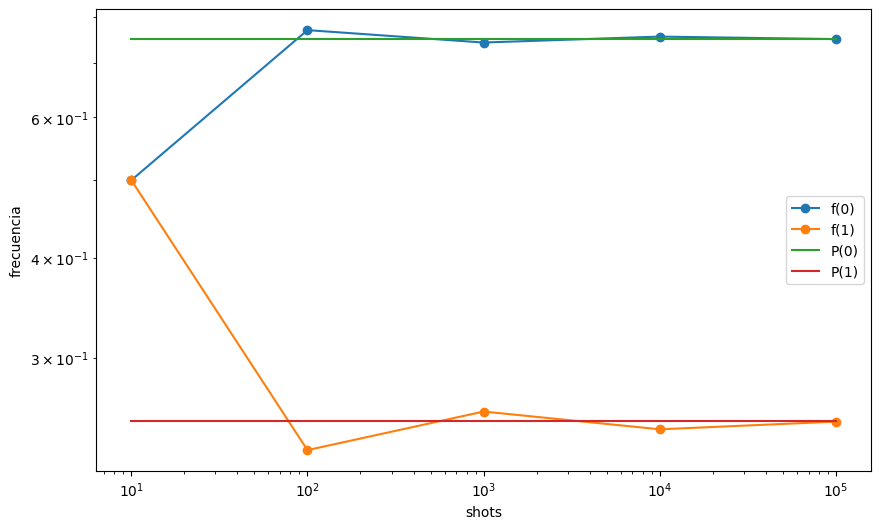

In [157]:
plt.figure(figsize=(10, 6))
shots = np.array([resultado['shots'] for resultado in resultados_experimento])
f0 = np.array([resultado['f0'] for resultado in resultados_experimento])
f1 = np.array([resultado['f1'] for resultado in resultados_experimento])

plt.loglog(shots, f0, marker='o', label='f(0)')
plt.loglog(shots, f1, marker='o', label='f(1)')
plt.loglog(shots, [p0] * len(shots), label='P(0)')
plt.loglog(shots, [p1] * len(shots), label='P(1)')
plt.xlabel('shots')
plt.ylabel('frecuencia')
plt.legend()
plt.xscale("log")
plt.show()


**Interpretación de la gráfica (4-6 líneas):**

Podemos observar en la gráfica como con pocos shots, f(0) y f(1) se desvían bastante del valor real de 0.75 y 0.25. Vemos que hay bastante fluctuación y que las frecuencias son variables aleatorias dadas la semilla originada al inicio. A medida que vamos aumentando el número de shots, la frecuencia se va aproximando a la probabilidad real. Esto se debe a la ley de los grandes números. En el eje x, los shots son logaritmicos, lo que permite ver la tendencia de decrecimiento. Cuanto más aumentemos la cantidad de shots, no necesariamente va a mejorar nuestra aproximación ya que la medida es aleatoria, es por eso que es importante interpretar los datos obtenidos. La convergencia no tiene por qué ser monótona por esto mismo.

### Ejercicio 10. Histograma de resultados

Para 1.000 shots, representa un diagrama de barras con los conteos de 0 y 1. Añade el valor numérico sobre cada barra.

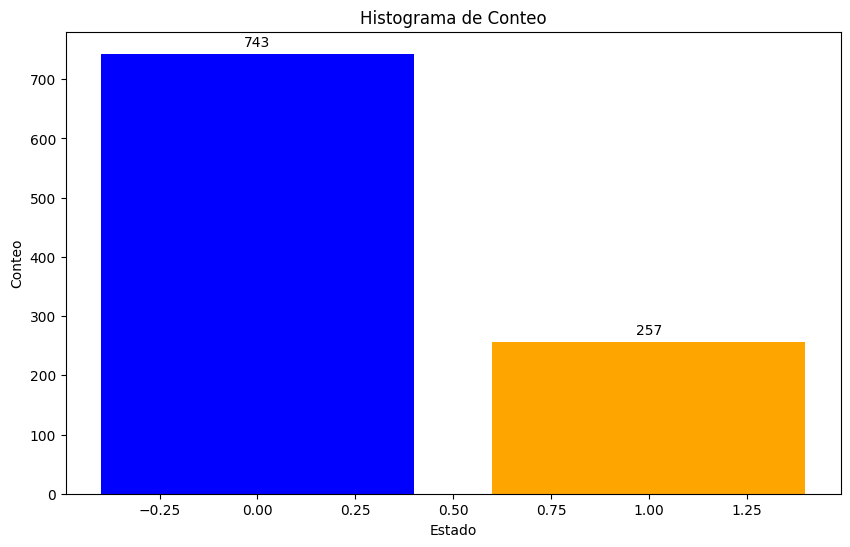

In [158]:
conteos_1000 = medir_repetidamente(psi_2, shots=1000, semilla=SEMILLA)
 
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(conteos_1000.keys(), conteos_1000.values(), color=['blue', 'orange'])

ax.bar_label(barras, padding=3)
ax.set_xlabel('Estado')
ax.set_ylabel('Conteo')
ax.set_title('Histograma de Conteo')


plt.show()
 

**Responde:** ¿Qué información muestra el histograma? ¿Muestra directamente las amplitudes? ¿Permite determinar la fase relativa?

**Respuesta:**

    - Muestra cuantas veces ha aparecido cada resultado. Una estimación estadística de la probabilidad de cada estado.
    - No directamente, solo estima las amplitudes por media de los conteos.
    - No. El histograma no muestra la fase relativa de los estados.


## Parte F. Estados con las mismas probabilidades

### Ejercicio 11. El papel de la fase

Compara los estados

$$|\psi_A\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},\qquad |\psi_B\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}},\qquad |\psi_C\rangle=\frac{|0\rangle+i|1\rangle}{\sqrt{2}}.$$

Represéntalos, valida su normalización, calcula sus probabilidades y simula 10.000 medidas de cada uno.

psi_A: vector = [0.70711+0.j 0.70711+0.j]
válido = True
P(0) = 0.5000, P(1) = 0.5000
10000 shots: 
N(0) = 5015, N(1) = 4985
f(0) = 0.5015, f(1) = 0.4985

psi_B: vector = [ 0.70711+0.j -0.70711+0.j]
válido = True
P(0) = 0.5000, P(1) = 0.5000
10000 shots: 
N(0) = 5015, N(1) = 4985
f(0) = 0.5015, f(1) = 0.4985

psi_C: vector = [0.70711+0.j      0.     +0.70711j]
válido = True
P(0) = 0.5000, P(1) = 0.5000
10000 shots: 
N(0) = 5015, N(1) = 4985
f(0) = 0.5015, f(1) = 0.4985



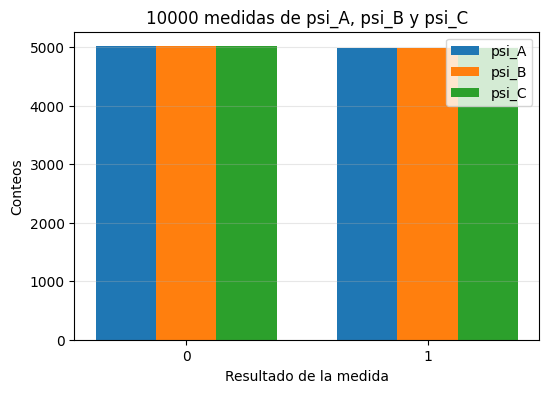

In [159]:
# TODO: representa y compara psi_A, psi_B y psi_C

psi_A = np.array([1,  1], dtype=complex) / np.sqrt(2)
psi_B = np.array([1, -1], dtype=complex) / np.sqrt(2)
psi_C = np.array([1, 1j], dtype=complex) / np.sqrt(2)

estados = {"psi_A": psi_A, "psi_B": psi_B, "psi_C": psi_C}
conteos_fases = {}

for i, (nombre, psi) in enumerate(estados.items()):
    prob = calcular_probabilidades(psi)
    conteos = medir_repetidamente(psi, shots=10000, semilla=SEMILLA)
    conteos_fases[nombre] = conteos
    
    print(f"{nombre}: vector = {psi}")
    print(f"válido = {es_estado_valido(psi)}")
    print(f"P(0) = {prob[0]:.4f}, P(1) = {prob[1]:.4f}")
    print(f"10000 shots: \nN(0) = {conteos[0]}, N(1) = {conteos[1]}")
    print(f"f(0) = {conteos[0]/10000:.4f}, f(1) = {conteos[1]/10000:.4f}")
    

    print()

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
ancho = 0.25
for k, (nombre, c) in enumerate(conteos_fases.items()):
    ax.bar(x + (k - 1) * ancho, [c[0], c[1]], ancho, label=nombre)
ax.set_xticks(x)
ax.set_xticklabels(["0", "1"])
ax.set_title("10000 medidas de psi_A, psi_B y psi_C")
ax.set_xlabel("Resultado de la medida")
ax.set_ylabel("Conteos")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.show()

**Responde:**

1. ¿Son iguales los tres vectores?
    - No. Son 3 vectores distintos, cada uno con su propia fase relativa.
2. ¿Producen las mismas probabilidades en la base computacional?
    - Si. Los 3 dan una probabilidad aproximada de 50% para cada estado.
3. ¿Podemos concluir que representan el mismo estado?
    - No. Los 3 vectores tienen diferentes fases relativas, lo que significa que no representan el mismo estado.
4. ¿Permite esta medida detectar sus diferencias?
    - No. Medir en base computacional no permite detectar las diferencias de fase.
5. ¿Qué información no aparece en los histogramas?
    - El histograma no muestra la información de las fases relativas de los vectores, ni el signo -1 o el factor i.
6. ¿Qué fenómeno permitirá aprovechar posteriormente estas diferencias?
    - La interferencia.

### Ejercicio 12. Fase global y fase relativa

Compara

$$|\phi_A\rangle=\frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix},\quad |\phi_B\rangle=-\frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix},\quad |\phi_C\rangle=\frac{1}{\sqrt{2}}\begin{pmatrix}1\\-1\end{pmatrix}.$$

¿Qué estados se diferencian solo por una fase global? ¿Dónde hay una diferencia de fase relativa? ¿Cuáles son físicamente equivalentes?

**Respuesta razonada:** 

*Fase global:* $\ket{\phi_B}$ y $-\ket{\phi_A}$, solo difieren por un factor global -1.

*Fase relativa:* $\ket{\phi_C}$ y $\ket{\phi_A}$, solo cambia el signo de la segunda componente por un factor de -1, este solo afecta a $\ket1$. El cociente de las componentes no es constante, hay una diferencia de fase relativa.

*Equivalentes:* $\ket{\phi_A}$ y $\ket{\phi_B}$ representan el mismo esstado físico porque la fase global no afecta a ninguna probabilidad medible. $\ket{\phi_C}$ y $\ket{\phi_A}$ son dos estados ortogonales.

## Parte G. Construcción segura de estados

### Ejercicio 13. Función de construcción

Completa una función que acepte amplitudes reales o complejas, rechace valores no finitos y el vector nulo, y devuelva el estado normalizado.

In [160]:
def crear_estado(alpha, beta):
    """Construye y normaliza el estado de un qubit."""
    try:
        vector = np.array([alpha, beta], dtype=complex)    
    except ValueError:
        print("Los coeficientes alpha y beta deben ser reales o complejos.")
        return None    
    return normalizar_estado(vector)

psi_nuevo = crear_estado(1+2j, 3-1j)
print("estado", psi_nuevo)
print("norma", np.linalg.norm(psi_nuevo))
print("probabilidades", calcular_probabilidades(psi_nuevo))

estado [0.2582+0.5164j 0.7746-0.2582j]
norma 0.9999999999999999
probabilidades {0: 0.3333333333333333, 1: 0.6666666666666666}


**Responde:** ¿Es siempre conveniente normalizar automáticamente una entrada? ¿En qué contexto sería preferible lanzar una excepción? ¿Puede la normalización ocultar un error matemático?

**Respuesta:** 

    - No. 
    - Conviene lanzar excepciones cuando las entradas vienen de otros cálculos o contextos. Así podemos detectar y corregir errores antes de que se propague.
    - Si.

## Reto avanzado. Incertidumbre estadística

Para una variable binaria con probabilidad $p$, la desviación típica de la frecuencia estimada con $N$ shots es

$$\sigma_f=\sqrt{\frac{p(1-p)}{N}}.$$

Con $p=0{,}75$, calcula $\sigma_f$ para todos los números de shots anteriores y añade a la gráfica las curvas $p-\sigma_f$ y $p+\sigma_f$.

In [161]:
# TODO: calcula sigma_f y representa las bandas de incertidumbre
p = 0.75

**Responde:** ¿Cómo varía la incertidumbre con $N$? ¿Cuántos shots hacen falta aproximadamente para reducirla a la mitad? ¿Por qué aumentar shots presenta rendimiento decreciente?

**Respuesta:** TODO

## Pruebas mínimas

Ejecuta estas pruebas después de completar las funciones y añade las necesarias para comprobar entradas no válidas.

In [162]:
# Descomenta cuando hayas implementado las funciones.

assert es_estado_valido([1, 0])
assert es_estado_valido([0, 1])
assert not es_estado_valido([1, 1])
assert not es_estado_valido([0, 0])
assert not es_estado_valido([1, 0, 0])
assert np.isclose(np.linalg.norm(normalizar_estado([1, 1])), 1.0)
assert np.isclose(sum(calcular_probabilidades(psi_2).values()), 1.0)
assert medir(psi_1, np.random.default_rng(42)) in (0, 1)
assert sum(medir_repetidamente(psi_2, 1000, 42).values()) == 1000

assert not es_estado_valido([np.nan, 0])
assert not es_estado_valido([np.inf, 0])
assert es_estado_valido(psi_3)
assert es_estado_valido(psi_4)

El estado no está normalizado.
El estado es el vector nulo.
El estado tiene forma (3,), pero debería ser (2,).
El estado contiene valores infinitos o NaN.
El estado contiene valores infinitos o NaN.


## Conclusiones

Redacta un máximo de 200 palabras respondiendo:

1. ¿Qué diferencia existe entre amplitud y probabilidad?
    - La amplitud es un numero complejo que describe el estado y contiene la fase, mientras que la probabilidad es el cuadrado de su módulo, un número real entre 0 y 1 que no conserva la fase.
2. ¿Qué relación existe entre shots, frecuencias y probabilidades?
    - Cada shot es una nueva preparación y medida del estado. Las frecuencias estiman las probabilidades de Born y convergen a ella con la cantidad de shots.
3. ¿Por qué una sola medida no permite reconstruir el estado?
    - Una sola medida devuelve un bit y colapsa el estado. Solo indica que ese resultado tenía probabilidad no nula, así que no permite reconstruir el estado original.
4. ¿Por qué dos estados diferentes pueden producir el mismo histograma?
    - Porque distintos estados pueden tener distintas fases mientras que tienen la misma $|\alpha|^2$ y $|\beta|^2$. Por ejemplo, $\ket{+} y \ket{-}$ tienen el mismo histograma.
5. ¿Qué diferencia conceptual existe entre una superposición y una mezcla clásica?
    - Una superposición es un único estado puro cuyas amplitudes pueden interferir. Una mezcla clásica es una combinación lineal de estados puros.

## Lista de comprobación antes de entregar

- [ ] Todas las celdas se ejecutan en orden sin errores.
- [ ] No quedan bloques `TODO` sin completar.
- [ ] Las probabilidades suman uno.
- [ ] Las gráficas tienen títulos, etiquetas y leyendas.
- [ ] Las respuestas justifican los resultados.
- [ ] Las pruebas mínimas se ejecutan correctamente.
- [ ] El notebook conserva las salidas antes de la entrega.